In [1]:
%pip install kagglehub
%pip install datasets
%pip install tensorflow
%pip install keras
%pip install pillow
%pip install dataset
%pip install torch
%pip install torchvision
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from PIL import Image

import torch

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchvision.models import vgg16, VGG16_Weights
from torchvision.utils import save_image
import random
from itertools import cycle


In [3]:
%pip install -U pip
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [4]:
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

torch: 2.11.0+cu126
cuda available: True
cuda version: 12.6
device count: 1


In [ ]:
#hyperparams
image_size = 256
batch_size = 4
steps = 1000
lr = 1e-3




#weights
content_weight = 7.00
style_weight = 45000.0  


#data in and out
content_folder = "val2017"
style_folder = "style_folder"
output_folder = "output"


#Test image
test_image = "IMG_7835.png"
resume = True





device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print("gpu")
else:
    print("cpu")



class img_dataset(Dataset):
    def __init__(self, folder):
        self.files = []
        for f in os.listdir(folder):
            if f.lower().endswith(".jpg"):
                full_path = os.path.join(folder, f)
                self.files.append(full_path)
        resize = transforms.Resize((image_size, image_size))
        to_tensor = transforms.ToTensor()

        self.transform = transforms.Compose([
            resize,
            to_tensor
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        img = Image.open(self.files[i]).convert("RGB")
        return self.transform(img)



#conditional instance norm
class cin(nn.Module):
    def __init__(self, channels, num_styles):
        super().__init__()

        self.norm = nn.InstanceNorm2d(channels, affine=False)
        self.gamma = nn.Embedding(num_styles, channels)
        self.beta = nn.Embedding(num_styles, channels)

        self.gamma.weight.data.fill_(1)
        self.beta.weight.data.zero_()

    def forward(self, x, style_id):
        x = self.norm(x)
        gamma = self.gamma(style_id).reshape(-1, x.size(1), 1, 1)
        beta = self.beta(style_id).reshape(-1, x.size(1), 1, 1)
        return gamma * x + beta



class conditional_transfer(nn.Module):
    def __init__(self, num_styles):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 9, 1, 4)
        self.norm1 = cin(32, num_styles)

        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.norm2 = cin(64, num_styles)

        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.norm3 = cin(128, num_styles)

        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        
        self.norm4 = cin(64, num_styles)

        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        
        self.norm5 = cin(32, num_styles)

        self.conv4 = nn.Conv2d(32, 3, 9, 1, 4)

    def forward(self, x, style_id):
        x = self.conv1(x)
        x = self.norm1(x, style_id)
        x = torch.relu(x)

        x = self.conv2(x)
        x = self.norm2(x, style_id)
        x = torch.relu(x)

        x = self.conv3(x)
        x = self.norm3(x, style_id)
        x = torch.relu(x)

        x = self.deconv1(x)
        x = self.norm4(x, style_id)
        x = torch.relu(x)

        x = self.deconv2(x)
        x = self.norm5(x, style_id)
        x = torch.relu(x)

        x = self.conv4(x)
        x = torch.sigmoid(x)

        return x


class loss_network(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = vgg16(
            weights=VGG16_Weights.IMAGENET1K_FEATURES).features[:16].eval()
        for p in self.layers.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.layers(x)


def gram_matrix(x):
    b, c, h, w = x.shape

    x = x.reshape(b, c, h * w)

    gram = torch.bmm(x, x.transpose(1,2))

    return gram / (c * h * w)


def normalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406],device=x.device).reshape(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225],device=x.device).reshape(1, 3, 1, 1)
    x = x - mean
    x = x / std
    return x


def load(path, device):
    t = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
])

    img = Image.open(path).convert("RGB")
    return t(img).unsqueeze(0).to(device)


os.makedirs(output_folder, exist_ok=True)

dataset = img_dataset(content_folder)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

style_files = []

all_style_files = os.listdir(style_folder)

for f in all_style_files:
    name = f.lower()

    if name.endswith(".jpg"):
        full = os.path.join(style_folder, f)
        style_files.append(full)
num_styles = len(style_files)

print("styles number:", num_styles)

vgg = loss_network().to(device)
mse = nn.MSELoss()

model = conditional_transfer(num_styles).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

checkpoint_path = os.path.join(output_folder, "conditional_model_checkpoint.pth")
model_path = os.path.join(output_folder, "conditional_model.pth")

start_step = 0

if resume and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_step = checkpoint["step"]
    print("Resuming: ", start_step)
else:
    print("Starting")


style_grams = []
for style_path in style_files:
    style_img = load(style_path, device)
    with torch.no_grad():
        style_feature = vgg(normalize(style_img))
        style_gram = gram_matrix(style_feature)

    style_grams.append(style_gram)


data_iter = iter(loader)

for step in range(start_step, start_step + steps):
    content = next(data_iter).to(device)

    style_id_number = step % num_styles

    num = content.size(0)

    style_ids = []
    i = 0
    while i < num:
        style_ids.append(style_id_number)
        i = i + 1

    style_id = torch.tensor(style_ids)
    style_id = style_id.to(device)
    output = model(content, style_id)

    content_feature = vgg(normalize(content))
    output_feature = vgg(normalize(output))

    loss_content = mse(output_feature, content_feature)
    target_style_gram = style_grams[style_id_number].expand(content.size(0), -1, -1)
    loss_style = mse(gram_matrix(output_feature), target_style_gram)
    weighted_content_loss = content_weight * loss_content
    weighted_style_loss = style_weight * loss_style

    loss = weighted_content_loss + weighted_style_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (step + 1) % 50 == 0:
        print(
            "step:",
            step + 1,
            "style id:",
            style_id_number,
            "loss:",
            float(loss),
            "weighted content loss:", 
            float(weighted_content_loss.detach()),
            "weighted style loss:", 
            float(weighted_style_loss.detach()),
        )

    if (step + 1) % 100 == 0:
        torch.save({
            "step": step + 1,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
        }, checkpoint_path)

        preview_path = os.path.join(output_folder, "preview.jpg")
        save_image(output[0].detach().cpu(), preview_path)


torch.save(model.state_dict(), model_path)

torch.save({
    "step": start_step + steps,
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
}, checkpoint_path)





gpu
styles number: 3
Resuming:  2200
step: 2250 style id: 2 loss: 2503.8193359375 weighted content loss: 1370.9256591796875 weighted style loss: 1132.8936767578125
step: 2300 style id: 1 loss: 2663.86181640625 weighted content loss: 1679.791015625 weighted style loss: 984.07080078125
step: 2350 style id: 0 loss: 3247.28564453125 weighted content loss: 1757.217041015625 weighted style loss: 1490.0687255859375
step: 2400 style id: 2 loss: 2314.310546875 weighted content loss: 1156.7069091796875 weighted style loss: 1157.6036376953125
step: 2450 style id: 1 loss: 2472.070556640625 weighted content loss: 1411.2747802734375 weighted style loss: 1060.7957763671875
step: 2500 style id: 0 loss: 3030.45654296875 weighted content loss: 1501.0240478515625 weighted style loss: 1529.4324951171875
step: 2550 style id: 2 loss: 2783.271484375 weighted content loss: 1657.364990234375 weighted style loss: 1125.9066162109375
step: 2600 style id: 1 loss: 2531.37744140625 weighted content loss: 1369.654663

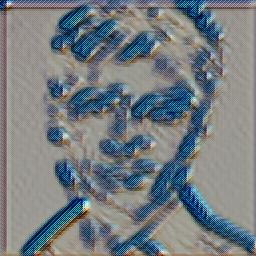

saved: output\resultdownload (1).jpg


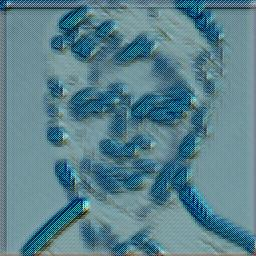

saved: output\resultJuan_Gris_-_Portrait_of_Pablo_Picasso_-_Google_Art_Project.jpg


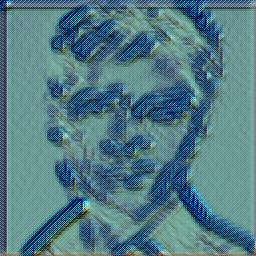

saved: output\resultVan_Gogh_-_Starry_Night_-_Google_Art_Project.jpg


In [ ]:
from IPython.display import display
from PIL import Image

if os.path.exists(test_image):
    test_t = load(test_image, device)

    style_i = 0
    while style_i < num_styles:
        style_file = style_files[style_i]
        base_name = os.path.basename(style_file)
        style_name = os.path.splitext(base_name)[0]


        ids = []
        ids.append(style_i)
        style_id = torch.tensor(ids)
        style_id = style_id.to(device)

        with torch.no_grad():
            result = model(test_t, style_id)

        file_name = "result" + style_name + ".jpg"
        result_path = os.path.join(output_folder, file_name)

        result_cpu = result[0].cpu()
        save_image(result_cpu, result_path)

        img = Image.open(result_path)
        display(img)

        print("saved:", result_path)

        style_i = style_i + 1
else:
    print("test image not found:", test_image)